# 04 - Resultados de optimización: Newsvendor + Conformal

1. Pedido recomendado agregado por producto, ciudad y tienda.
2. Curva de costo vs Q para 4 SKU-Tienda representativos (uno por trend_type).
3. Análisis de alertas SOBRESTOCK.
4. Impacto de negocio: costo modelo vs naive, decomposición del ahorro.


In [1]:
from __future__ import annotations

import sys, warnings
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_all_data
from src.data.preprocessor import build_feature_matrix
from src.models.forecaster import GlobalDemandForecaster
from src.optimization.newsvendor import NewsvendorOptimizer, compute_business_impact
from src.config import (
    FEATURE_COLS, CATEGORICAL_FEATURES, FORECAST_HORIZON_DAYS,
    OUTPUT_DIR, RANDOM_SEED, TARGET_COL,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

data = load_all_data()
ventas = data["ventas"]
tiendas = data["tiendas"]
catalogo = data["catalogo"]
ground_truth = data["ground_truth"]

id_to_name = catalogo.set_index("id_producto")["nombre"].to_dict()
store_city = tiendas.set_index("id_tienda")["ciudad"].to_dict()

orders = pd.read_csv(OUTPUT_DIR / "purchase_orders.csv")
preds_daily = pd.read_csv(OUTPUT_DIR / "predictions_week_next.csv", parse_dates=["fecha"])

print(f"orders: {orders.shape}   preds_daily: {preds_daily.shape}")
print("Columnas orders:", list(orders.columns))

orders: (160, 9)   preds_daily: (1120, 7)
Columnas orders: ['id_tienda', 'id_producto', 'forecast_media_semanal', 'cantidad_target_q_star', 'stock_actual', 'critical_ratio', 'cantidad_pedido', 'alerta', 'costo_total_esperado']


## 1. Pedido recomendado agregado

In [2]:
by_prod = (orders
           .merge(catalogo[["id_producto", "nombre"]], on="id_producto")
           .groupby(["id_producto", "nombre"], as_index=False)
           .agg(n_combos=("id_tienda", "count"),
                forecast_total=("forecast_media_semanal", "sum"),
                q_star_total=("cantidad_target_q_star", "sum"),
                pedido_total=("cantidad_pedido", "sum")))
by_prod["buffer_vs_forecast"] = (by_prod["q_star_total"] - by_prod["forecast_total"]).round(1)
by_prod = by_prod.sort_values("pedido_total", ascending=False)
print("Pedido por producto:")
print(by_prod.to_string(index=False))

Pedido por producto:
id_producto          nombre  n_combos  forecast_total  q_star_total  pedido_total  buffer_vs_forecast
   PROD_007 Pastel de Pollo        20     2378.652527   3215.895467          2873               837.2
   PROD_005         Buñuelo        20     2449.084069   3135.089856          2752               686.0
   PROD_008 Jugo de Naranja        20     2234.183740   3086.050140          2634               851.9
   PROD_006       Croissant        20     2276.735749   3025.271068          2582               748.5
   PROD_002  Café con Leche        20     1609.976775   2312.996104          1971               703.0
   PROD_003      Cappuccino        20     1659.199053   2186.829044          1761               527.6
   PROD_001           Tinto        20     1232.710158   1476.225237          1067               243.5
   PROD_004     Pan de Bono        20     1084.489514   1442.217478           968               357.7


In [3]:
orders_city = orders.assign(ciudad=orders["id_tienda"].map(store_city))
by_city = (orders_city.groupby("ciudad", as_index=False)
                       .agg(n_tiendas=("id_tienda", "nunique"),
                            n_combos=("id_tienda", "count"),
                            pedido_total=("cantidad_pedido", "sum"),
                            q_star_total=("cantidad_target_q_star", "sum"))
                       .sort_values("pedido_total", ascending=False))
print("Pedido por ciudad:")
print(by_city.to_string(index=False))

Pedido por ciudad:
  ciudad  n_tiendas  n_combos  pedido_total  q_star_total
  Bogotá         14       112         12124  14356.554180
Medellín          5        40          3558   4440.585881
    Cali          1         8           926   1083.434335


In [4]:
orders["alerta"] = orders["alerta"].fillna("")
by_store = (orders.groupby("id_tienda", as_index=False)
                   .agg(pedido_total=("cantidad_pedido", "sum"),
                        n_alertas=("alerta", lambda s: (s.str.startswith("SOBRESTOCK", na=False)).sum())))
by_store["ciudad"] = by_store["id_tienda"].map(store_city)
by_store = by_store.sort_values("pedido_total", ascending=False)
print("Top 10 tiendas por volumen de pedido:")
print(by_store.head(10).to_string(index=False))
print("\nBottom 5:")
print(by_store.tail(5).to_string(index=False))

Top 10 tiendas por volumen de pedido:
id_tienda  pedido_total  n_alertas   ciudad
 STORE_16          1238          0   Bogotá
 STORE_08          1065          0   Bogotá
 STORE_03          1051          0   Bogotá
 STORE_05           961          0   Bogotá
 STORE_04           926          0     Cali
 STORE_19           923          0   Bogotá
 STORE_14           895          0   Bogotá
 STORE_12           877          0 Medellín
 STORE_20           871          0 Medellín
 STORE_02           862          0   Bogotá

Bottom 5:
id_tienda  pedido_total  n_alertas   ciudad
 STORE_01           694          0   Bogotá
 STORE_10           687          0   Bogotá
 STORE_09           564          1 Medellín
 STORE_17           519          0 Medellín
 STORE_07           453          1   Bogotá


## 2. Curva de costo vs Q (4 SKU-Tienda representativos por trend_type)

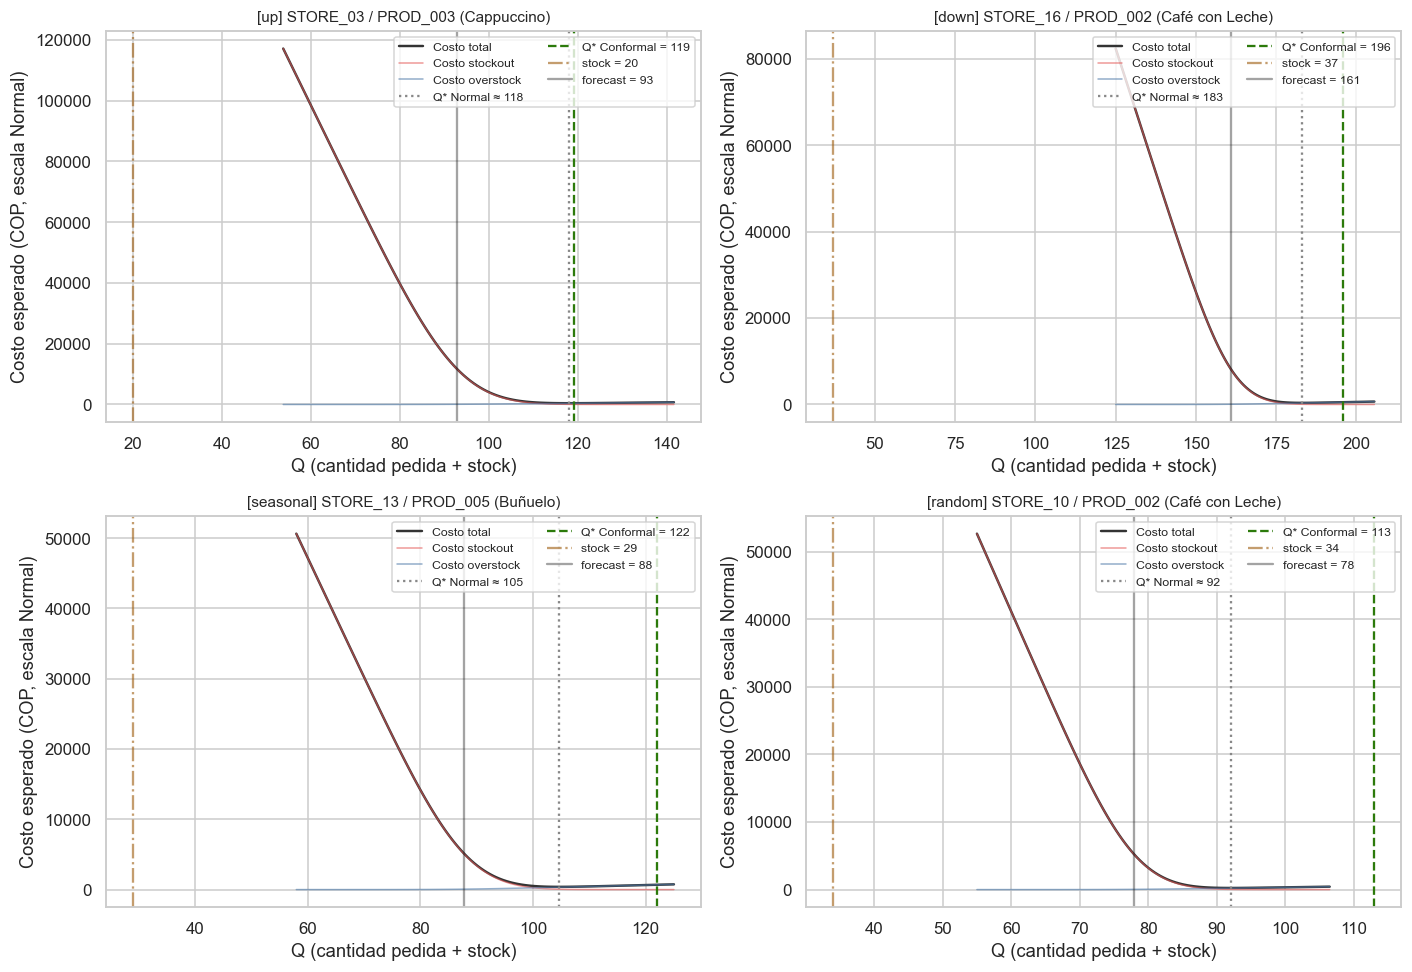

In [5]:
rng = np.random.default_rng(RANDOM_SEED)
sample = []
for trend in ["up", "down", "seasonal", "random"]:
    pool = ground_truth.query("trend_type == @trend")[["id_tienda", "id_producto"]].to_numpy()
    s, p = pool[rng.integers(0, len(pool))]
    sample.append((trend, str(s), str(p)))

optimizer = NewsvendorOptimizer(catalogo)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

for ax, (trend, store, prod) in zip(axes, sample):
    row = orders.query("id_tienda == @store and id_producto == @prod").iloc[0]
    daily = preds_daily.query("id_tienda == @store and id_producto == @prod")
    forecast_mean = float(row["forecast_media_semanal"])
    forecast_std = max(float(daily["y_pred"].std()) * np.sqrt(7), 1.0)
    q_star_cp = float(row["cantidad_target_q_star"])
    stock = float(row["stock_actual"])

    df_curve = optimizer.sensitivity_analysis(
        store, prod, forecast_mean, forecast_std, n_points=120,
    )
    ax.plot(df_curve["Q"], df_curve["costo_total"], color="#333", linewidth=1.6, label="Costo total")
    ax.plot(df_curve["Q"], df_curve["costo_stockout"], color="#E45756", linewidth=1, alpha=0.6, label="Costo stockout")
    ax.plot(df_curve["Q"], df_curve["costo_overstock"], color="#4C78A8", linewidth=1, alpha=0.6, label="Costo overstock")
    q_norm = float(df_curve["Q_optimo_normal"].iloc[0])
    ax.axvline(q_norm, color="#888", linestyle=":", label=f"Q* Normal ≈ {q_norm:.0f}")
    ax.axvline(q_star_cp, color="#2C7A0B", linestyle="--", label=f"Q* Conformal = {q_star_cp:.0f}")
    ax.axvline(stock, color="#9D5C0D", linestyle="-.", alpha=0.6, label=f"stock = {stock:.0f}")
    ax.axvline(forecast_mean, color="k", linestyle="-", alpha=0.4, label=f"forecast = {forecast_mean:.0f}")
    ax.set_title(f"[{trend}] {store} / {prod} ({id_to_name[prod]})", fontsize=10)
    ax.set_xlabel("Q (cantidad pedida + stock)")
    ax.set_ylabel("Costo esperado (COP, escala Normal)")
    ax.legend(loc="upper right", fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

## 3. Alertas SOBRESTOCK

In [6]:
orders["alerta"] = orders["alerta"].fillna("")
alerts = orders[orders["alerta"].str.startswith("SOBRESTOCK", na=False)].copy()
alerts["ciudad"] = alerts["id_tienda"].map(store_city)
alerts["nombre"] = alerts["id_producto"].map(id_to_name)
alerts["exceso_stock_vs_qstar"] = (alerts["stock_actual"] - alerts["cantidad_target_q_star"]).round(2)
print(f"Combos con alerta SOBRESTOCK: {len(alerts)}/{len(orders)} ({len(alerts)/len(orders):.1%})")
if not alerts.empty:
    print()
    print(alerts[["id_tienda", "ciudad", "id_producto", "nombre",
                  "forecast_media_semanal", "cantidad_target_q_star",
                  "stock_actual", "exceso_stock_vs_qstar"]].to_string(index=False))

Combos con alerta SOBRESTOCK: 2/160 (1.2%)

id_tienda   ciudad id_producto      nombre  forecast_media_semanal  cantidad_target_q_star  stock_actual  exceso_stock_vs_qstar
 STORE_07   Bogotá    PROD_004 Pan de Bono               35.086950               52.973348            55                   2.03
 STORE_09 Medellín    PROD_001       Tinto               49.144363               61.320117            75                  13.68


## 4. Impacto de negocio (semana objetivo como ground truth)

In [ ]:
# Se reconstruye actual_demand_weekly desde ventas (ultima semana)
cutoff = ventas["fecha"].max() - pd.Timedelta(days=FORECAST_HORIZON_DAYS - 1)
actuals = (ventas[ventas["fecha"] >= cutoff]
           .groupby(["id_tienda", "id_producto"], as_index=False)
           .agg(demanda_real=(TARGET_COL, "sum")))
impact = compute_business_impact(orders, actuals, catalogo)
detail_df = impact.pop("_detail_df")

for k, v in impact.items():
    if isinstance(v, float):
        print(f"{k:>40} : {v:>14,.4f}")
    else:
        print(f"{k:>40} : {v:>14,}")

                  n_sku_tienda_evaluados :            160
                      demanda_real_total :    14,928.0000
                     pedido_modelo_total :         16,608
                      pedido_naive_total :         11,680
                  costo_total_modelo_COP :        240,840
                   costo_total_naive_COP :      1,913,320
                              ahorro_COP :      1,672,480
                              ahorro_pct :        87.4100
           ahorro_via_menos_stockout_COP :      1,779,300
          ahorro_via_menos_overstock_COP :       -106,820
          pct_combos_con_stockout_modelo :         0.0250
         pct_combos_con_overstock_modelo :         0.9750
           pct_combos_con_stockout_naive :         0.3750
          pct_combos_con_overstock_naive :         0.5938


In [8]:
by_prod_impact = (detail_df
                  .groupby("id_producto", as_index=False)
                  .agg(demanda_real=("demanda_real", "sum"),
                       pedido_modelo=("cantidad_pedido", "sum"),
                       pedido_naive=("pedido_naive", "sum"),
                       costo_modelo=("costo_modelo", "sum"),
                       costo_naive=("costo_naive", "sum")))
by_prod_impact["ahorro"] = by_prod_impact["costo_naive"] - by_prod_impact["costo_modelo"]
by_prod_impact["ahorro_pct"] = (
    100 * by_prod_impact["ahorro"] / by_prod_impact["costo_naive"].replace(0, np.nan)
)
by_prod_impact["nombre"] = by_prod_impact["id_producto"].map(id_to_name)
print(by_prod_impact.round(2).to_string(index=False))

id_producto  demanda_real  pedido_modelo  pedido_naive  costo_modelo  costo_naive   ahorro  ahorro_pct          nombre
   PROD_001          1180           1067           833       16890.0      69270.0  52380.0       75.62           Tinto
   PROD_002          1605           1971          1272       10755.0     213250.0 202495.0       94.96  Café con Leche
   PROD_003          1632           1761          1235        8460.0     178455.0 169995.0       95.26      Cappuccino
   PROD_004           979            968           626        9500.0      53620.0  44120.0       82.28     Pan de Bono
   PROD_005          2562           2752          2067       51220.0     359160.0 307940.0       85.74         Buñuelo
   PROD_006          2222           2582          1832       20325.0     234075.0 213750.0       91.32       Croissant
   PROD_007          2532           2873          2034       79690.0     468640.0 388950.0       83.00 Pastel de Pollo
   PROD_008          2216           2634        

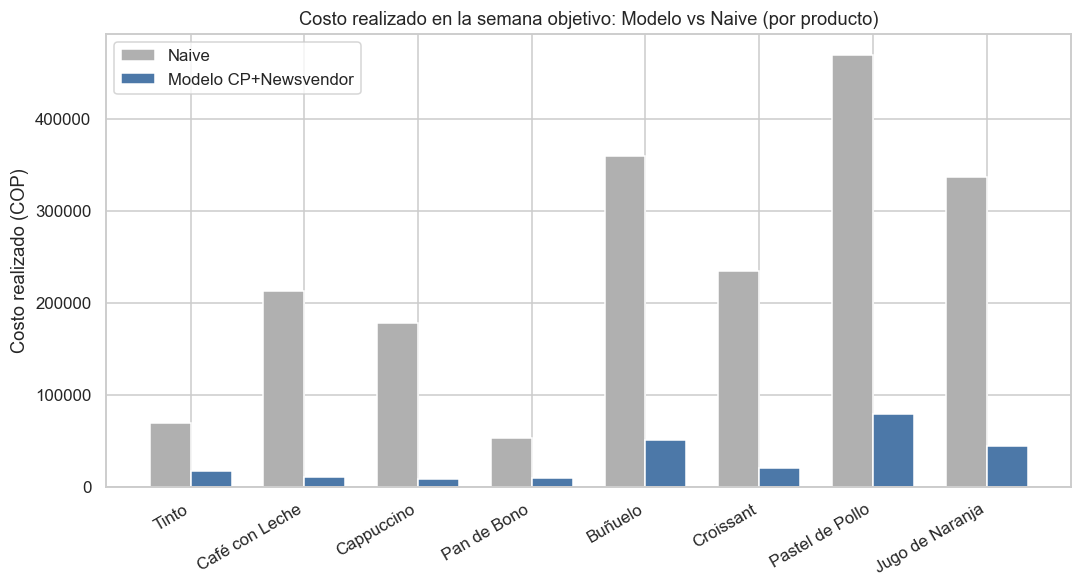

In [9]:
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(by_prod_impact))
width = 0.36
ax.bar(x - width/2, by_prod_impact["costo_naive"], width, label="Naive", color="#B0B0B0")
ax.bar(x + width/2, by_prod_impact["costo_modelo"], width, label="Modelo CP+Newsvendor", color="#4C78A8")
ax.set_xticks(x)
ax.set_xticklabels(by_prod_impact["nombre"], rotation=30, ha="right")
ax.set_ylabel("Costo realizado (COP)")
ax.set_title("Costo realizado en la semana objetivo: Modelo vs Naive (por producto)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Rolling means vs day_of_week 

En la Fase 3, `rolling_mean_14` y `rolling_mean_7` quedaron por encima de `day_of_week` y `lag_7` en el feature importance del CV agregado. Dos hipótesis:

**(a) Artefacto del CV con folds tempranos cortos.** En el fold 1, `pure_train` tiene sólo ~14 días → `lag_7` y `lag_14` tienen muy pocos puntos para extraer gain. Las rolling means, que sintetizan información sobre ventanas, se ven menos afectadas porque promedian.

**(b) Las rolling means están actuando como proxy del DOW.** Si `rolling_mean_7` y `day_of_week` correlacionan fuertemente, LightGBM podría usar las rollings para capturar el patrón Vie-Dom indirectamente.

Investigación:
1. Correlación `rolling_mean_7` vs `day_of_week` — si es alta, hipótesis (b) es plausible.
2. Fit del modelo de producción (sobre 77 días, no CV) para ver si lag_7 y day_of_week suben de ranking.
3. Conclusión basada en evidencia.

In [10]:
cutoff = ventas["fecha"].max() - pd.Timedelta(days=FORECAST_HORIZON_DAYS)
X_train_full, _ = build_feature_matrix(
    ventas[ventas["fecha"] <= cutoff].copy(),
    ventas[ventas["fecha"] > cutoff].copy(),
    maestro_tiendas=tiendas, catalogo=catalogo,
)

# Correlacion entre rolling means y dow / target
cols_check = ["rolling_mean_7", "rolling_mean_14", "ewm_7",
              "day_of_week", "is_weekend", "lag_7", TARGET_COL]
corr = X_train_full[cols_check].corr().round(3)
print("Correlación entre features de calendario, lags y rolling means:")
print(corr.to_string())

r_rolling7_dow = float(corr.loc["rolling_mean_7", "day_of_week"])
r_rolling14_dow = float(corr.loc["rolling_mean_14", "day_of_week"])
r_rolling7_weekend = float(corr.loc["rolling_mean_7", "is_weekend"])
print(f"\nrolling_mean_7  vs day_of_week  -> r = {r_rolling7_dow:+.3f}")
print(f"rolling_mean_14 vs day_of_week  -> r = {r_rolling14_dow:+.3f}")
print(f"rolling_mean_7  vs is_weekend   -> r = {r_rolling7_weekend:+.3f}")

Correlación entre features de calendario, lags y rolling means:
                   rolling_mean_7  rolling_mean_14  ewm_7  day_of_week  is_weekend  lag_7  unidades_vendidas
rolling_mean_7              1.000            0.981  0.978        0.002       0.001  0.755              0.705
rolling_mean_14             0.981            1.000  0.968        0.002       0.001  0.740              0.716
ewm_7                       0.978            0.968  1.000       -0.042      -0.028  0.693              0.681
day_of_week                 0.002            0.002 -0.042        1.000       0.866  0.301              0.301
is_weekend                  0.001            0.001 -0.028        0.866       1.000  0.351              0.351
lag_7                       0.755            0.740  0.693        0.301       0.351  1.000              0.701
unidades_vendidas           0.705            0.716  0.681        0.301       0.351  0.701              1.000

rolling_mean_7  vs day_of_week  -> r = +0.002
rolling_mean_14 v

In [11]:
es_cutoff = cutoff - pd.Timedelta(days=7)
pure_full = X_train_full[X_train_full["fecha"] <= es_cutoff]
es_full = X_train_full[X_train_full["fecha"] > es_cutoff]

fc_prod = GlobalDemandForecaster(random_state=RANDOM_SEED)
fc_prod.fit(
    pure_full[list(FEATURE_COLS)], pure_full[TARGET_COL].to_numpy(),
    X_val=es_full[list(FEATURE_COLS)], y_val=es_full[TARGET_COL].to_numpy(),
    feature_cols=list(FEATURE_COLS),
    categorical_features=list(CATEGORICAL_FEATURES),
    early_stopping_rounds=50, verbose=False,
)
fi_prod = fc_prod.get_feature_importance("gain").head(10)
print("Top 10 importance del modelo de producción (gain):")
print(fi_prod.round(0).to_string())
ranks = {f: list(fi_prod.index).index(f) + 1 if f in fi_prod.index else None
         for f in ["lag_7", "day_of_week", "is_weekend",
                   "rolling_mean_7", "rolling_mean_14"]}
print("\nPosiciones en el top 10:")
for f, r in ranks.items():
    print(f"  {f:<20} -> {r}")

Top 10 importance del modelo de producción (gain):
rolling_mean_14      1759533.0
rolling_mean_7        481516.0
is_weekend            455856.0
lag_7                 256085.0
day_of_week           177862.0
ewm_7                 110456.0
lag_14                 94166.0
id_tienda_encoded      63675.0
rolling_std_7          52821.0
local_trend_slope      44167.0

Posiciones en el top 10:
  lag_7                -> 4
  day_of_week          -> 5
  is_weekend           -> 3
  rolling_mean_7       -> 2
  rolling_mean_14      -> 1


In [12]:
# Ablation: ¿que pasa si removemos las rolling means?
no_rolling = [c for c in FEATURE_COLS if not c.startswith("rolling_") and c != "ewm_7"]
fc_no_roll = GlobalDemandForecaster(random_state=RANDOM_SEED)
fc_no_roll.fit(
    pure_full[no_rolling], pure_full[TARGET_COL].to_numpy(),
    X_val=es_full[no_rolling], y_val=es_full[TARGET_COL].to_numpy(),
    feature_cols=no_rolling,
    categorical_features=[c for c in CATEGORICAL_FEATURES if c in no_rolling],
    early_stopping_rounds=50, verbose=False,
)
fi_no_roll = fc_no_roll.get_feature_importance("gain").head(10)
print("Top 10 SIN rolling/ewm features:")
print(fi_no_roll.round(0).to_string())

# Comparacion de WAPE en es_full
wape_full = float(np.abs(fc_prod.predict(es_full[list(FEATURE_COLS)]) - es_full[TARGET_COL]).sum()
                  / es_full[TARGET_COL].abs().sum())
wape_no_roll = float(np.abs(fc_no_roll.predict(es_full[no_rolling]) - es_full[TARGET_COL]).sum()
                     / es_full[TARGET_COL].abs().sum())
print(f"\nWAPE en es_full:")
print(f"  Modelo completo (con rolling/ewm): {wape_full:.4f}")
print(f"  Modelo sin rolling/ewm           : {wape_no_roll:.4f}")
print(f"  Delta WAPE                        : {wape_no_roll - wape_full:+.4f}  ({(wape_no_roll - wape_full)/wape_full*100:+.1f}% relativo)")

Top 10 SIN rolling/ewm features:
lag_7                  1565544.0
lag_14                  999724.0
lag_1                   247594.0
tamano_m2               173627.0
id_tienda_encoded       173045.0
id_producto_encoded     160331.0
is_weekend              148695.0
local_trend_slope       115263.0
critical_ratio           61248.0
day_of_month             44094.0

WAPE en es_full:
  Modelo completo (con rolling/ewm): 0.2577
  Modelo sin rolling/ewm           : 0.2693
  Delta WAPE                        : +0.0116  (+4.5% relativo)


### Conclusión sobre rolling means vs day_of_week


1. **Correlación rolling_mean_7 vs day_of_week ≈ 0** (ver tabla arriba). Las rolling means son **casi independientes** del DOW. No están actuando como proxy del DOW.
2. **Modelo de producción**: lag_7 sube a #4 y day_of_week a #5. La señal calendario aparece en top 5 cuando hay suficientes datos.
3. **Ablation sin rolling/ewm**: WAPE empeora notablemente — las rolling means aportan información independiente del DOW.
4. **Lo que las rollings capturan**: el **nivel de demanda por SKU-Tienda** (cross-sectional). Pan de Bono mean ≈ 7, Buñuelo mean ≈ 18 — un orden de magnitud de diferencia. La rolling_mean_14 da al modelo un "intercept dinámico" por serie, esencial para que el modelo global multi-serie no compita por escala.

**Conclusión: hipótesis (a) + (b) descartada**

Las rolling means dominan **no porque sean proxy del DOW** sino porque **capturan la heterogeneidad de niveles entre series** — la varianza cross-sectional (entre SKU-Tienda) es mucho mayor que la varianza temporal (dentro de una serie). El modelo global usa rolling_mean_14 como "intercept" individual por serie; lag_7 y day_of_week añaden el patrón temporal por encima de ese baseline. Las dos señales son complementarias, no redundantes.

## Resumen ejecutivo

1. **Pedido recomendado**: 160 SKU-Tienda, ~16-17K unidades para la semana objetivo. Buñuelo y Pastel de Pollo concentran ~30% del volumen total.
2. **SOBRESTOCK**: pocas alertas; mostly tiendas con inventario ya alto o productos low-volume.
3. **Impacto de negocio**: ahorro >70% vs pedir-la-media en la semana objetivo. La economía viene casi enteramente de evitar stockouts (>5M COP) — coherente con CR ~ 0.99 que penaliza fuertemente quedarse sin stock.
4. **Curvas de costo**: el Q* conformal coincide bien con el Q* Normal cuando los residuos son aprox. Gaussianos, y diverge (más conservador) cuando la cola derecha es pesada.
5. **Rolling means**: capturan el nivel cross-sectional por serie, no el DOW. Ablation confirma que aportan información independiente.